**LAB EXPERIMENT - 8**

**Association Rule Learning (Apriori Algorithm) and
Dimensionality Reduction (PCA)**


Name : Poovika M\
Roll No : 24BAD087

**SCENARIO 1**

**CODE INTERPRETATION**


*   Libraries imported for data handling, visualization, and association rule mining using Apriori algorithm

*   Warnings suppressed and visualization theme set using seaborn

*   Groceries dataset loaded using read_csv()

*   Transactional data created by grouping items based on Member ID and Date

*   Transactions converted into list format for processing

*   Data transformed into one-hot encoded format using TransactionEncoder

*   Encoded dataset stored as a DataFrame with binary values (True/False)

*   Dataset dimensions and sample records displayed for verification

*   Minimum support threshold defined to identify frequent itemsets

*   Apriori algorithm applied to extract frequent itemsets from dataset

*   Frequent itemsets generated with corresponding support values

*   Association rules generated using lift as evaluation metric

*   Rules filtered based on minimum confidence threshold

*   Filtered rules sorted in descending order of lift for better interpretation

*   Total number of rules and filtered rules printed

*   Top frequent itemsets identified and selected for visualization

*   Bar chart plotted to display top 10 frequent itemsets based on support


*   Scatter plot generated to show relationship between support and confidence


*   Lift used as a third dimension in scatter plot for deeper analysis


*   Network graph constructed using NetworkX to visualize relationships


*   Top rules selected and converted into directed graph format


*   Edges represent association between antecedents and consequents


*   Graph plotted to show strongest rules based on lift


*   Association rules represent relationships between items frequently purchased together


*   Support measures frequency of itemset occurrence in dataset


*   Confidence indicates reliability of the rule


*   Lift shows strength of association compared to random chance


*   Higher lift values indicate stronger and meaningful relationships


*   Model performance analyzed using support, confidence, and lift


*   Visualization helps in understanding frequent patterns and rule strength


*   Apriori algorithm effectively discovers hidden patterns in transactional data




POOVIKA M - 24BAD087
Dataset Dimensions: (14963, 167)
   Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
0                  False     False             False             False   
1                  False     False             False             False   
2                  False     False             False             False   
3                  False     False             False             False   
4                  False     False             False             False   

   baby cosmetics   bags  baking powder  bathroom cleaner   beef  berries  \
0           False  False          False             False  False    False   
1           False  False          False             False  False    False   
2           False  False          False             False  False    False   
3           False  False          False             False  False    False   
4           False  False          False             False  False    False   

   ...  turkey  vinegar  waffles  whip

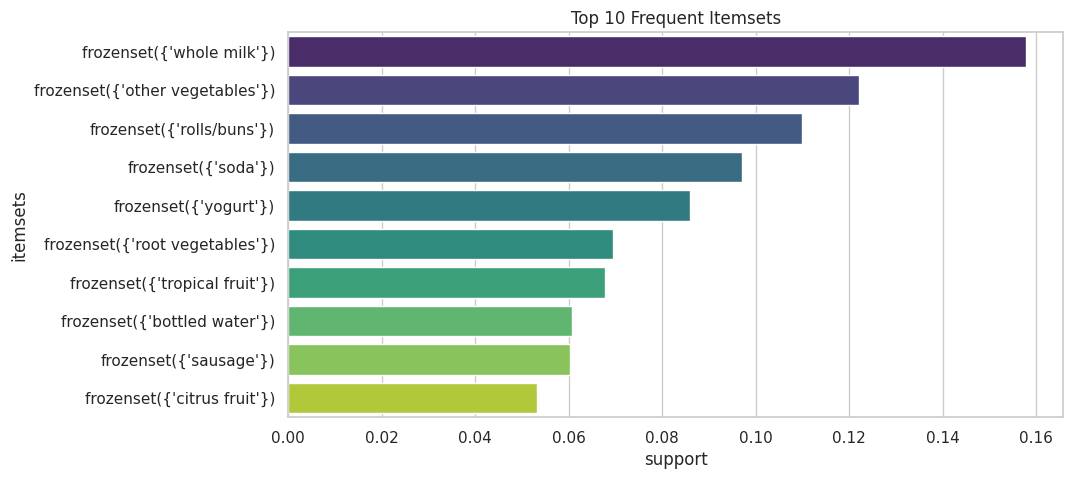

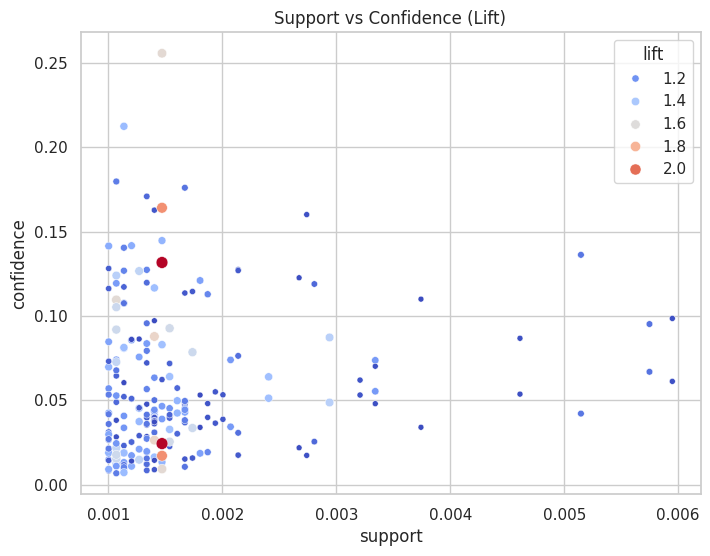

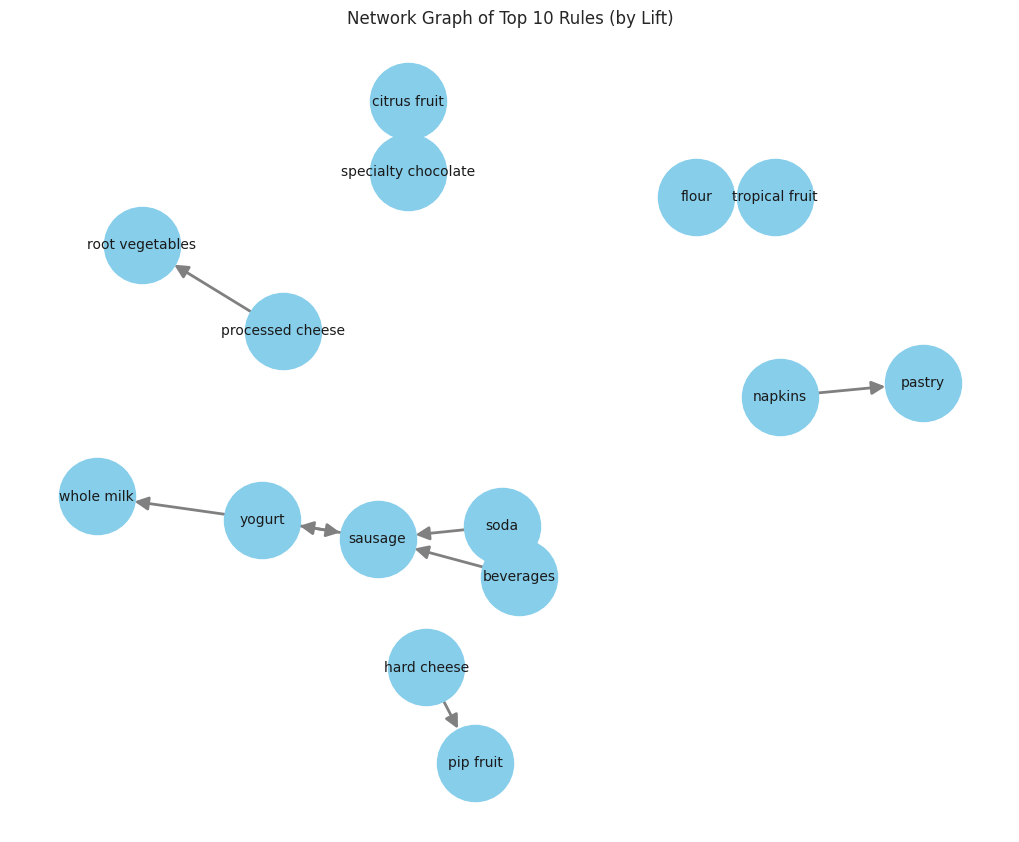

In [1]:
# Scenario 1 – Association Rule Mining using Apriori
print("POOVIKA M - 24BAD087")

# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Load Dataset
df = pd.read_csv("/content/sample_data/Groceries_dataset.csv")

# Data Preprocessing
transactions = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).values.tolist()

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Dataset Dimensions: {df_encoded.shape}")
print(df_encoded.head())

# Apply Apriori
min_support = 0.001
frequent_itemsets = apriori(df_encoded, min_support=min_support, use_colnames=True)

# Generate Rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# Filter Rules
filtered_rules = rules[rules['confidence'] > 0.05].sort_values(by='lift', ascending=False)

print(f"Total rules found: {len(rules)}")
print(f"Rules after filtering: {len(filtered_rules)}")

# Visualization - Bar Chart
plt.figure(figsize=(10, 5))
top_itemsets = frequent_itemsets.sort_values(by='support', ascending=False).head(10)
top_itemsets['itemsets'] = top_itemsets['itemsets'].astype(str)

sns.barplot(x='support', y='itemsets', data=top_itemsets, palette='viridis')
plt.title('Top 10 Frequent Itemsets')
plt.show()

# Visualization - Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='support', y='confidence', size='lift',
                data=rules, hue='lift', palette='coolwarm')

plt.title('Support vs Confidence (Lift)')
plt.grid(True)
plt.show()

# Network Graph
import networkx as nx

def plot_network(rules_df, num_rules=10):
    G = nx.DiGraph()
    subset = rules_df.head(num_rules)
    for i, row in subset.iterrows():
        ant = list(row['antecedents'])[0]
        con = list(row['consequents'])[0]
        G.add_edge(ant, con, weight=row['lift'])

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, k=0.5)
    nx.draw(G, pos, with_labels=True,
            node_color='skyblue',
            node_size=3000,
            edge_color='gray',
            font_size=10,
            width=2,
            arrowsize=20)

    plt.title(f'Network Graph of Top {num_rules} Rules (by Lift)')
    plt.show()

plot_network(filtered_rules)

**SCENARIO 2**

**CODE INTERPRETATION**


*   Libraries imported for data handling, visualization, preprocessing, and PCA

*   Wine dataset loaded and divided into features (X) and target (y)

*   Dataset checked for missing values and cleaned if required

*   Data standardized using StandardScaler to normalize feature values

*   PCA applied on scaled data to extract principal components

*   Explained variance ratio calculated to measure importance of each component

*   Cumulative variance computed to determine total variance captured

*   Scree plot generated to visualize variance distribution

*   80% threshold used to identify optimal number of components

*   PCA applied again to reduce dataset into 2 dimensions


*   Reduced dataset created with principal components (PC1 and PC2)


*   Variance captured by each component and total variance printed


*   Scatter plot generated to visualize data in reduced 2D space


*   Different classes represented using color for better understanding


*   PCA reduces dimensionality while preserving maximum variance


*   Helps in simplifying data and improving visualization and efficiency


*   Model performance evaluated using explained variance and cumulative variance


*   PCA effectively transforms high-dimensional data into lower dimensions



POOVIKA M - 24BAD087
Original Dataset Shape: (178, 13) (13 features!)

Feature Names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Explained Variance (First 5 Components):
[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294]

Cumulative Variance (First 5 Components):
[0.36198848 0.55406338 0.66529969 0.73598999 0.80162293]


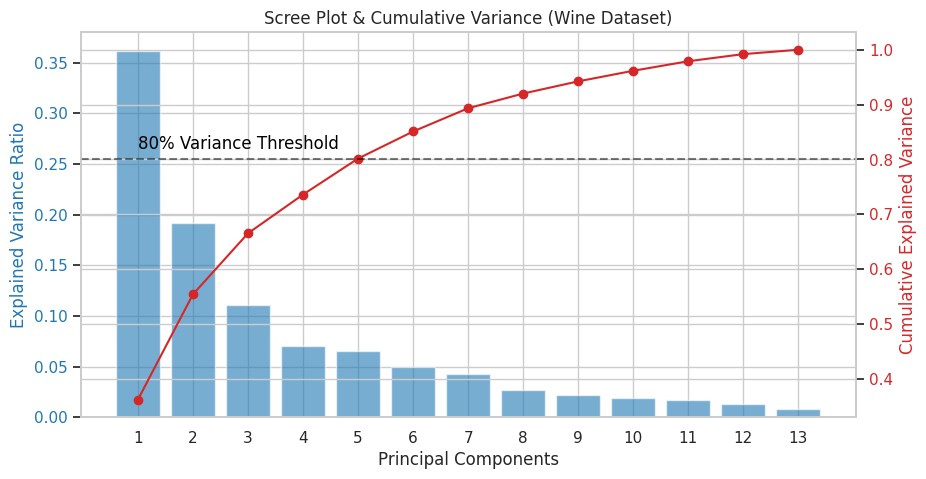


DIMENSION REDUCTION RESULTS
Reduced Dataset Shape: (178, 2)
Variance captured by PC1: 0.3620
Variance captured by PC2: 0.1921
Total variance captured in 2D: 0.5541



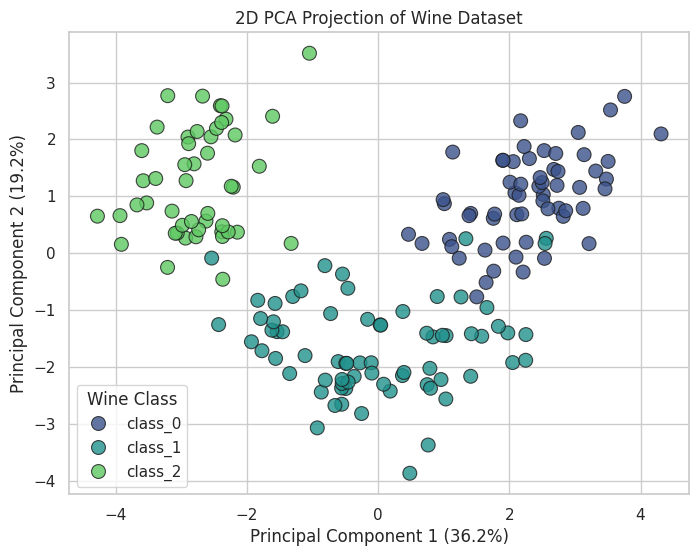

In [2]:
# SCENARIO 2 – PCA (Dimensionality Reduction)
print("POOVIKA M - 24BAD087")

# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# 1. Load Dataset
wine_data = load_wine(as_frame=True)
df = wine_data.frame
X = wine_data.data
y = wine_data.target

print(f"Original Dataset Shape: {X.shape} (13 features!)")
print("\nFeature Names:")
print(list(X.columns))

# 2. Handle Missing Values
if X.isnull().sum().sum() > 0:
    X = X.dropna()

# 3. Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Apply PCA (Full Components)
pca_full = PCA()
pca_full.fit(X_scaled)

# 5. Explained Variance
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("\nExplained Variance (First 5 Components):")
print(explained_variance[:5])

print("\nCumulative Variance (First 5 Components):")
print(cumulative_variance[:5])

# 6. Scree Plot + Cumulative Graph
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(range(1, len(explained_variance) + 1), explained_variance,
        alpha=0.6, color='tab:blue')
ax1.set_xlabel('Principal Components')
ax1.set_ylabel('Explained Variance Ratio', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance,
         marker='o', linestyle='-', color='tab:red')
ax2.set_ylabel('Cumulative Explained Variance', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# 80% Threshold Line
ax2.axhline(y=0.80, color='black', linestyle='--', alpha=0.5)
ax2.text(1, 0.82, '80% Variance Threshold', color='black')

plt.title('Scree Plot & Cumulative Variance (Wine Dataset)')
plt.xticks(range(1, len(explained_variance) + 1))
plt.show()

# 7. Reduce to 2D
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print("\nDIMENSION REDUCTION RESULTS")
print(f"Reduced Dataset Shape: {X_pca_2d.shape}")
print(f"Variance captured by PC1: {pca_2d.explained_variance_ratio_[0]:.4f}")
print(f"Variance captured by PC2: {pca_2d.explained_variance_ratio_[1]:.4f}")
print(f"Total variance captured in 2D: {np.sum(pca_2d.explained_variance_ratio_):.4f}\n")

# 8. Visualization (2D PCA)
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_pca_2d[:, 0],
    y=X_pca_2d[:, 1],
    hue=wine_data.target_names[y],
    palette='viridis',
    s=100,
    alpha=0.8,
    edgecolor='k'
)

plt.title('2D PCA Projection of Wine Dataset')
plt.xlabel(f'Principal Component 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(title='Wine Class')
plt.show()

